# Bid landscape simulation

In [18]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def simulate_market_cpm(
    n=500_000,
    d=6,
    seed=42,

    # Market price (CPM) model: log m_cpm = mu(x) + sigma * eps
    mu0=np.log(1.5),          # baseline median ~ $1.5 CPM when features are ~0
    beta_scale=0.35,          # feature effect on log-CPM
    sigma=0.75,               # lognormal spread

    # Conversion/value model
    base_cvr=2e-4,            # typical display CVR per impression scale (0.0002)
    theta_scale=1.0,          # feature effect on CVR (via sigmoid)
    value_per_conv=50.0,      # $ per conversion (can be arbitrary)
    
    # Bidding rule in CPM dollars
    kappa=0.25,               # scales how aggressively we bid vs value
    bid_cpm_min=0.01,
    bid_cpm_max=20.0,
):
    rng = np.random.default_rng(seed)

    # 1) features
    X = rng.normal(size=(n, d))

    # 2) market price in CPM dollars
    beta = rng.normal(scale=beta_scale, size=d)
    mu = mu0 + X @ beta
    eps = rng.normal(size=n)
    log_m_cpm = mu + sigma * eps
    m_cpm = np.exp(log_m_cpm)  # market clearing price in CPM dollars

    # 3) conversion probability per impression (keep it small!)
    theta = rng.normal(scale=theta_scale, size=d)
    p = sigmoid(X @ theta)                 # in (0,1)
    p_conv = base_cvr * p                  # in (0, base_cvr)

    # 4) value per impression in dollars, then convert to CPM dollars
    value_per_imp_dollars = value_per_conv * p_conv
    value_cpm = 1000.0 * value_per_imp_dollars

    # 5) bid policy (CPM)
    bid_cpm = kappa * value_cpm
    bid_cpm = np.clip(bid_cpm, bid_cpm_min, bid_cpm_max)

    # 6) win + pay (pay = market price if win; 0 otherwise)
    win = (bid_cpm >= m_cpm).astype(np.int8)
    pay_cpm = m_cpm * win
    pay_dollars = pay_cpm / 1000.0

    return {
        "X": X,
        "market_price_cpm": m_cpm,
        "bid_cpm": bid_cpm,
        "win": win,
        "pay_cpm": pay_cpm,
        "pay_dollars": pay_dollars,
        "p_conv": p_conv,
        "value_cpm": value_cpm,
        "params": {"mu0": mu0, "beta": beta, "sigma": sigma}
    }

# Mixture Model

In [19]:
def simulate_market_cpm_mixture(
    n=300_000,
    d=6,
    seed=42,

    # Two lognormal components in log-CPM space:
    # log M_k = mu_k(x) + sigma_k * eps
    mu0_1=np.log(1.0),         # component 1 baseline median ~$1.0
    mu0_2=np.log(3.0),         # component 2 baseline median ~$3.0
    beta_scale_1=0.25,
    beta_scale_2=0.25,
    sigma1=0.65,
    sigma2=0.85,

    # Mixing weight: pi(x)=P(component=2 | x)
    # If pi_feat_scale=0 => constant mixing prob pi0
    pi0=0.25,                  # unconditional weight on expensive regime
    pi_feat_scale=1.0,         # set 0.0 for constant mixing

    # Optional: keep same value/bid pipeline as before
    base_cvr=2e-4,
    theta_scale=1.0,
    value_per_conv=50.0,
    kappa=0.25,
    bid_cpm_min=0.05,
    bid_cpm_max=10.0,
):
    rng = np.random.default_rng(seed)

    # 1) features
    X = rng.normal(size=(n, d))

    # 2) mixture weight pi(x)
    if pi_feat_scale == 0.0:
        pi = np.full(n, pi0)
        pi_params = {"pi0": pi0, "pi_feat_scale": 0.0, "a": None}
    else:
        a = rng.normal(scale=pi_feat_scale, size=d)
        # shift so average ~ pi0
        logits = X @ a + np.log(pi0 / (1 - pi0))
        pi = sigmoid(logits)
        pi_params = {"pi0": pi0, "pi_feat_scale": pi_feat_scale, "a": a}

    # sample component: c=1 is expensive regime (component 2), c=0 is cheap regime (component 1)
    c = (rng.random(n) < pi).astype(np.int8)

    # 3) component-specific mu(x)
    beta1 = rng.normal(scale=beta_scale_1, size=d)
    beta2 = rng.normal(scale=beta_scale_2, size=d)
    mu1 = mu0_1 + X @ beta1
    mu2 = mu0_2 + X @ beta2

    # 4) sample log-CPM from selected component
    eps = rng.normal(size=n)
    log_m = np.where(c == 0, mu1 + sigma1 * eps, mu2 + sigma2 * eps)
    m_cpm = np.exp(log_m)

    # 5) value model -> bid (same as before)
    theta = rng.normal(scale=theta_scale, size=d)
    p = sigmoid(X @ theta)
    p_conv = base_cvr * p

    value_per_imp_dollars = value_per_conv * p_conv
    value_cpm = 1000.0 * value_per_imp_dollars

    bid_cpm = np.clip(kappa * value_cpm, bid_cpm_min, bid_cpm_max)

    # 6) win + pay (synthetic: pay=market price if win)
    win = (bid_cpm >= m_cpm).astype(np.int8)
    pay_cpm = m_cpm * win
    pay_dollars = pay_cpm / 1000.0

    return {
        "X": X,
        "market_price_cpm": m_cpm,
        "component": c,  # 0=cheap, 1=expensive
        "pi": pi,        # mixing prob for expensive component
        "bid_cpm": bid_cpm,
        "win": win,
        "pay_cpm": pay_cpm,
        "pay_dollars": pay_dollars,
        "p_conv": p_conv,
        "value_cpm": value_cpm,
        "params": {
            "mu0_1": mu0_1, "mu0_2": mu0_2,
            "beta1": beta1, "beta2": beta2,
            "sigma1": sigma1, "sigma2": sigma2,
            **pi_params
        }
    }

In [20]:
def bid_landscape_curves(market_price_cpm, bid_grid_cpm):
    """
    Returns:
      win_rate[b] = P(win | bid=b)
      e_cpm[b]    = E[pay_cpm per impression | bid=b]
    """
    m = market_price_cpm[:, None]     # (n,1)
    B = bid_grid_cpm[None, :]         # (1,K)
    win = (B >= m)                    # (n,K)
    win_rate = win.mean(axis=0)       # (K, )
    e_pay_cpm = (m * win).mean(axis=0)  # expected paid CPM per impression# (K, )
    return win_rate, e_pay_cpm

# Plot bid landscape curves

(80,)
(80,)


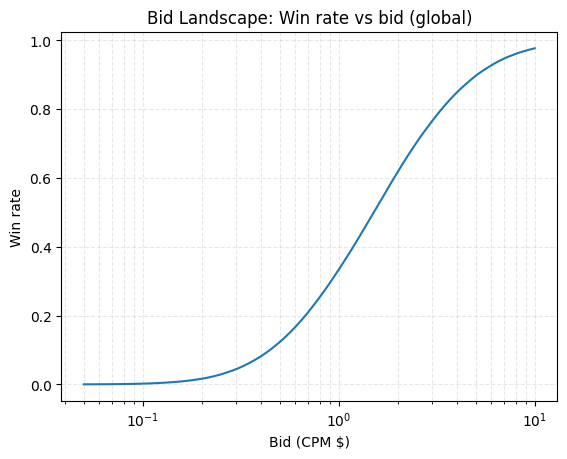

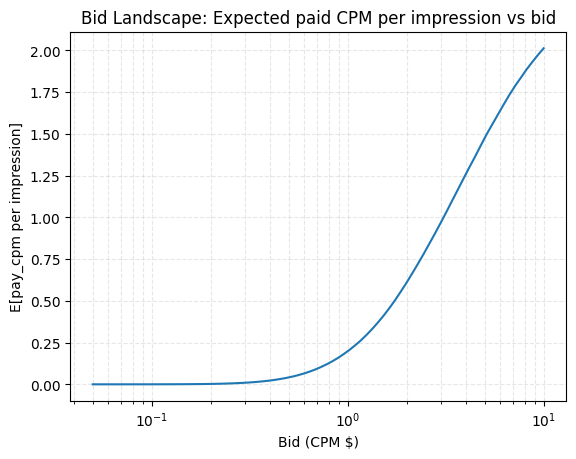

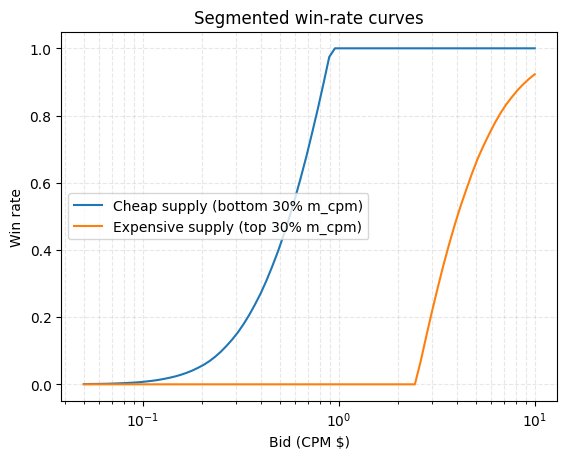

In [21]:
import matplotlib.pyplot as plt

sim = simulate_market_cpm(
    n=300_000, d=6, seed=7,
    mu0=np.log(1.5), beta_scale=0.35, sigma=0.75,
    base_cvr=2e-4, value_per_conv=50.0,
    kappa=0.25,
    bid_cpm_min=0.05, bid_cpm_max=10.0,   # force bids into your target range
)

m = sim["market_price_cpm"]
bids = np.geomspace(0.05, 10.0, 80)

win_rate, e_pay_cpm = bid_landscape_curves(m, bids)

print(win_rate.shape)
print(e_pay_cpm.shape)

# 1) Global win-rate curve
plt.figure()
plt.semilogx(bids, win_rate)
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Bid Landscape: Win rate vs bid (global)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# 2) Global expected spend (CPM) per impression
plt.figure()
plt.semilogx(bids, e_pay_cpm)
plt.xlabel("Bid (CPM $)")
plt.ylabel("E[pay_cpm per impression]")
plt.title("Bid Landscape: Expected paid CPM per impression vs bid")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# 3) Segment the landscape by "supply expensiveness" (top/bottom 30% by market price)
q_lo, q_hi = np.quantile(m, [0.3, 0.7])
seg_lo = m <= q_lo
seg_hi = m >= q_hi

wr_lo, e_lo = bid_landscape_curves(m[seg_lo], bids)
wr_hi, e_hi = bid_landscape_curves(m[seg_hi], bids)

plt.figure()
plt.semilogx(bids, wr_lo, label="Cheap supply (bottom 30% m_cpm)")
plt.semilogx(bids, wr_hi, label="Expensive supply (top 30% m_cpm)")
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Segmented win-rate curves")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# Simple log-likelihood fit
Market CPM multi-variant-log-normal model with parameters M ~ (w, b and $\sigma$)
- $
Y = \log M, \qquad 
Y \mid x \sim \mathcal{N}(\mu(x), \sigma^2), \qquad 
\mu(x) = w^\top x + b
$  

We fit w, b and $\sigma$ based on  
- All impressions contribute win/loss likelihood (Cases A/B)
- Wins with prices additionally contribute density likelihood 

In [32]:
import numpy as np
from math import sqrt, pi

# Stable normal CDF/PDF approximations (good enough for training)
def normal_pdf(z):
    return np.exp(-0.5 * z**2) / sqrt(2*pi)

def normal_cdf(z):
    # Abramowitz-Stegun approximation for erf-based CDF
    # Phi(z)=0.5*(1+erf(z/sqrt(2)))
    # We'll use a fast approximation to erf for numpy arrays.
    # erf(x) approx: sign(x)*sqrt(1-exp(-x^2*(4/pi + a*x^2)/(1+a*x^2)))
    a = 0.147
    x = z / sqrt(2)
    sign = np.sign(x)
    xx = x*x
    erf = sign * np.sqrt(1 - np.exp(-xx*(4/pi + a*xx)/(1 + a*xx)))
    return 0.5 * (1 + erf)

def fit_lognormal_censored(
    X, bid_cpm, win,
    win_price_cpm=None,      # array same length as X, NaN where missing
    lr=0.05,
    steps=2000,
    l2=1e-4,
    seed=0
):
    """
    Model: log M ~ N(mu(x), sigma^2), mu(x)=b + w^T x
    Observations:
      - loss: M > bid => log-survival
      - win no price: M <= bid => log-CDF
      - win with price: log-density at observed log(price)
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape

    # Add intercept column
    X1 = np.concatenate([np.ones((n,1)), X], axis=1)  # (n, d+1)
    D = d + 1

    # params
    theta = rng.normal(scale=0.01, size=D)  # intercept + weights
    log_sigma = np.log(0.8)                 # reasonable init

    eps = 1e-12

    # prepare logs
    t = np.log(np.clip(bid_cpm, 1e-6, None))

    has_price = None
    y = None
    if win_price_cpm is not None:
        has_price = np.isfinite(win_price_cpm) & (win == 1)
        y = np.log(np.clip(win_price_cpm, 1e-6, None))
    else:
        has_price = np.zeros(n, dtype=bool)

    win = win.astype(np.int8)

    for s in range(steps):
        sigma = np.exp(log_sigma)
        mu = X1 @ theta                    # (n,)
        zt = (t - mu) / sigma              # (n,)
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        phi = np.clip(normal_pdf(zt), eps, None)

        # ---- Loss / Win(no price) terms ----
        # logL = win_no_price * log Phi + loss * log(1-Phi)
        win_no_price = (win == 1) & (~has_price)
        loss = (win == 0)

        # Gradients w.r.t mu and sigma for these terms:
        # For log Phi(zt): d/dmu = -(1/sigma) * (phi/Phi)
        # For log(1-Phi): d/dmu = +(1/sigma) * (phi/(1-Phi))
        ratio_win = phi / Phi
        ratio_loss = phi / (1 - Phi)

        dL_dmu = np.zeros(n)
        dL_dsigma = np.zeros(n)

        # win no price
        dL_dmu[win_no_price] += -(1/sigma) * ratio_win[win_no_price]
        dL_dsigma[win_no_price] += -(zt[win_no_price]/sigma) * ratio_win[win_no_price]

        # loss
        dL_dmu[loss] += +(1/sigma) * ratio_loss[loss]
        dL_dsigma[loss] += +(zt[loss]/sigma) * ratio_loss[loss]

        # ---- Win with observed price density terms ----
        # log f_Y(y) = -log sigma + log phi((y-mu)/sigma)
        # where zy = (y - mu)/sigma
        if has_price.any():
            idx = np.where(has_price)[0]
            zy = (y[idx] - mu[idx]) / sigma
            # d/dmu: +(zy / sigma)
            dL_dmu[idx] += zy / sigma
            # d/dsigma: (-1/sigma) + (zy^2 / sigma)
            dL_dsigma[idx] += (-1/sigma) + (zy**2 / sigma)

        # Convert to gradients for theta and log_sigma
        # mu = X1 theta  => dL/dtheta = X1^T dL/dmu
        grad_theta = X1.T @ dL_dmu / n - l2 * theta
        # sigma = exp(log_sigma): dL/dlog_sigma = dL/dsigma * sigma
        grad_log_sigma = (dL_dsigma.sum() / n) * sigma

        # Ascent on log-likelihood
        theta += lr * grad_theta
        log_sigma += lr * grad_log_sigma

        if (s+1) % 200 == 0:
            # compute average log-likelihood (for monitoring)
            sigma = np.exp(log_sigma)
            mu = X1 @ theta
            zt = (t - mu) / sigma
            Phi = np.clip(normal_cdf(zt), eps, 1 - eps)

            ll = 0.0
            ll += np.log(Phi[win_no_price]).sum()
            ll += np.log(1 - Phi[loss]).sum()

            if has_price.any():
                zy = (y[has_price] - mu[has_price]) / sigma
                ll += (-np.log(sigma) - 0.5*zy*zy - 0.5*np.log(2*np.pi)).sum()

            ll /= n
            print(f"step {s+1:4d}  avg_ll={ll:.6f}  sigma={np.exp(log_sigma):.3f}")

    return {
        "theta": theta,          # intercept + weights
        "sigma": np.exp(log_sigma)
    }

In [33]:
# sim = simulate_market_cpm(n=300_000, d=6, seed=7, bid_cpm_min=0.05, bid_cpm_max=10.0)
# X = sim["X"]
# bid = sim["bid_cpm"]
# win = sim["win"].astype(np.int8)
# print(X.shape, bid.shape, win.shape)

sim = simulate_market_cpm_mixture(
    n=300_000, d=6, seed=7,
    mu0_1=np.log(0.8),
    mu0_2=np.log(4.0),
    sigma1=0.6,
    sigma2=0.9,
    pi0=0.25,
    pi_feat_scale=1.0,  # set 0.0 to make mixture weight constant
    bid_cpm_min=0.05, bid_cpm_max=10.0
)

m = sim["market_price_cpm"]
win_rate, e_pay_cpm = bid_landscape_curves(m, bids)

In [34]:
# Observe price only for some wins (e.g., 30% of wins)
rng = np.random.default_rng(0)
win_price = np.full_like(bid, np.nan, dtype=float)
mask = (win == 1) & (rng.random(len(win)) < 0.30)
win_price[mask] = sim["pay_cpm"][mask]   # equals market_price_cpm in our synthetic world
print(win_price.shape)

fit = fit_lognormal_censored(X, bid, win, win_price_cpm=win_price, lr=0.08, steps=2000)
print("Fitted model:", fit)
print("Fitted sigma:", fit["sigma"])

(300000,)
step  200  avg_ll=-0.928054  sigma=7.610
step  400  avg_ll=-0.899117  sigma=7.184
step  600  avg_ll=-0.877660  sigma=7.005
step  800  avg_ll=-0.862150  sigma=6.967
step 1000  avg_ll=-0.850822  sigma=6.996
step 1200  avg_ll=-0.842361  sigma=7.054
step 1400  avg_ll=-0.835887  sigma=7.127
step 1600  avg_ll=-0.830818  sigma=7.204
step 1800  avg_ll=-0.826769  sigma=7.283
step 2000  avg_ll=-0.823477  sigma=7.360
Fitted model: {'theta': array([ 2.41218724,  0.4142773 , -2.18435285, -1.20012577, -1.61399379,
       -1.02225789, -2.098348  ]), 'sigma': np.float64(7.360359631621515)}
Fitted sigma: 7.360359631621515


# Global win-rate curve

In [29]:
def predict_winrate(fit, X, bid_grid_cpm):
    n, d = X.shape
    X1 = np.concatenate([np.ones((n,1)), X], axis=1)
    mu = X1 @ fit["theta"]
    sigma = fit["sigma"]
    t = np.log(bid_grid_cpm[None, :])
    z = (t - mu[:, None]) / sigma
    Phi = normal_cdf(z)
    return Phi.mean(axis=0)  # average over X

bids = np.geomspace(0.05, 10.0, 80)
wr_hat = predict_winrate(fit, X[:50_000], bids)  # use a sample

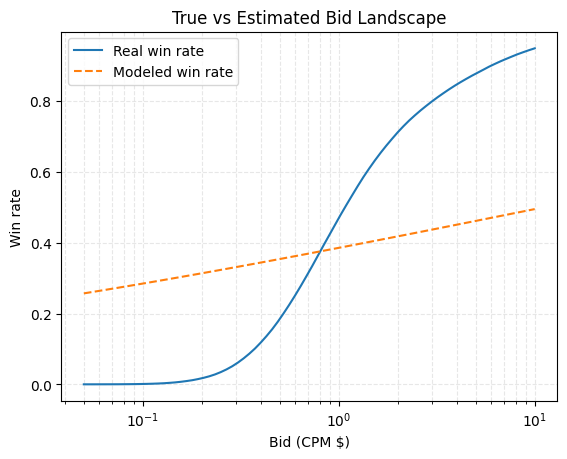

0.2569027572358601 0.4949455475039141


In [31]:
plt.figure()
plt.semilogx(bids, win_rate, label="Real win rate")
plt.semilogx(bids, wr_hat, label="Modeled win rate", linestyle="--")
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("True vs Estimated Bid Landscape")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.show()

# print(wr_hat.shape)
# print(win_rate.shape)
# dis = np.linalg.norm(win_rate-wr_hat, ord=2)
# err_percentage = 2*dis/(np.linalg.norm(win_rate) + np.linalg.norm(wr_hat))
# print(dis)
# print(err_percentage)